In [1]:
import zipfile
import os
from PIL import Image


In [2]:
import zipfile
import os

# Path to your ZIP file
zip_path = "imageClassificationdEwast data.zip"
extract_path = "unzipped_dataset"  # This folder will be created

# Unzipping
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset unzipped to:", extract_path)


✅ Dataset unzipped to: unzipped_dataset


In [3]:
import os
from PIL import Image
import traceback

# Set your dataset root path
dataset_root = 'unzipped_dataset'  # Change this!

# Supported image formats
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff')

corrupted_images = []

# Walk through all subfolders and files
for root, dirs, files in os.walk(dataset_root):
    for file in files:
        if file.lower().endswith(valid_extensions):
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # This checks for corruption
            except (IOError, SyntaxError, Exception):
                print(f"❌ Corrupted: {img_path}")
                corrupted_images.append(img_path)
                try:
                    os.remove(img_path)
                    print(f"🗑️ Removed: {img_path}")
                except Exception as e:
                    print(f"⚠️ Failed to delete: {img_path}\n{e}")

print(f"\n✅ Done! Total corrupted images removed: {len(corrupted_images)}")



✅ Done! Total corrupted images removed: 0


In [4]:
import os
from collections import defaultdict

def count_images_in_directory(root_dir):
    image_counts = defaultdict(int)  # Automatically starts count at 0

    for root, dirs, files in os.walk(root_dir):  # Go through every folder and file inside root_dir
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):  # Check if file is an image
                # Get class name (which is the folder name one level above the file)
                class_name = os.path.basename(os.path.dirname(os.path.join(root, file)))
                image_counts[class_name] += 1  # Increase count for that class

    return dict(image_counts)  # Convert to normal dictionary for display

# 👉 Replace this with your actual dataset folder path (example: "dataset/train")
root_dir = "unzipped_dataset"  
image_counts = count_images_in_directory(root_dir)

print("Image Count per Class:")
for label, count in image_counts.items():
    print(f"{label}: {count}")


Image Count per Class:
Battery: 300
Keyboard: 300
Microwave: 300
Mobile: 300
Mouse: 300
PCB: 300
Player: 300
Printer: 300
Television: 300
Washing Machine: 300


In [11]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

root_dir = "C:/Users/BHARANIDHARAN.S/unzipped_dataset/modified-dataset/train/Battery"  # ✅ update if needed

# Step 1: List all class folders
class_names = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
print("✅ Class folders found:", class_names)

# Step 2: Count images per class and try to display
plt.figure(figsize=(15, len(class_names) * 2.5))
img_index = 1

for class_name in class_names:
    class_path = os.path.join(root_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"📁 {class_name}: {len(image_files)} image(s)")

    if len(image_files) == 0:
        continue  # skip empty folders

    # Show just one random image per class
    img_name = random.choice(image_files)
    img_path = os.path.join(class_path, img_name)
    try:
        img = mpimg.imread(img_path)
        plt.subplot(len(class_names), 1, img_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
        img_index += 1
    except Exception as e:
        print(f"❌ Error displaying {img_path}: {e}")

plt.tight_layout()
plt.show()


✅ Class folders found: []


<Figure size 1500x0 with 0 Axes>

🔍 Folder Structure:
modified-dataset/
    test/
        Battery/
            battery_106.jpg
            battery_128.jpg
            battery_148.jpg
            battery_152.jpg
            battery_174.jpg
            battery_177.jpg
            battery_190.jpg
            battery_192.jpg
            battery_211.jpg
            battery_22.jpg
            battery_24.jpg
            battery_241.jpg
            battery_242.jpg
            battery_251.jpg
            battery_259.jpg
            battery_260.jpg
            battery_264.jpg
            battery_266.jpg
            battery_267.jpg
            battery_275.jpg
            battery_279.jpg
            battery_282.jpg
            battery_284.jpg
            battery_294.jpg
            battery_4.jpg
            battery_40.jpg
            battery_61.jpg
            battery_75.jpg
            battery_83.jpg
            battery_92.jpg
        Keyboard/
            Keyboard_106.jpg
            Keyboard_128.jpg
            Keyboard_148.jpg

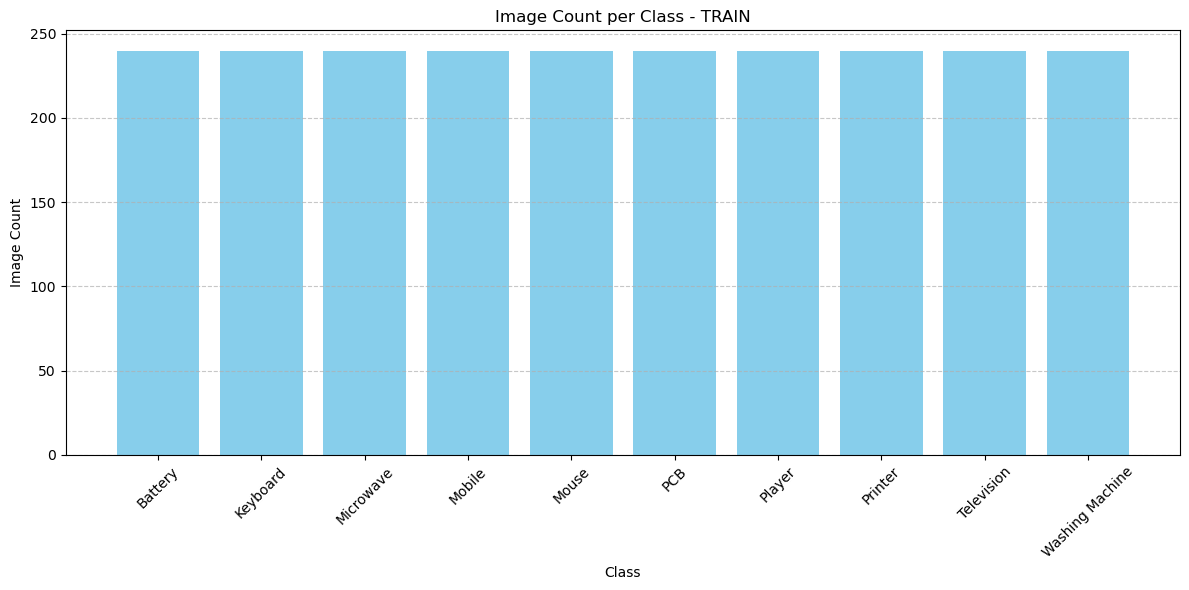

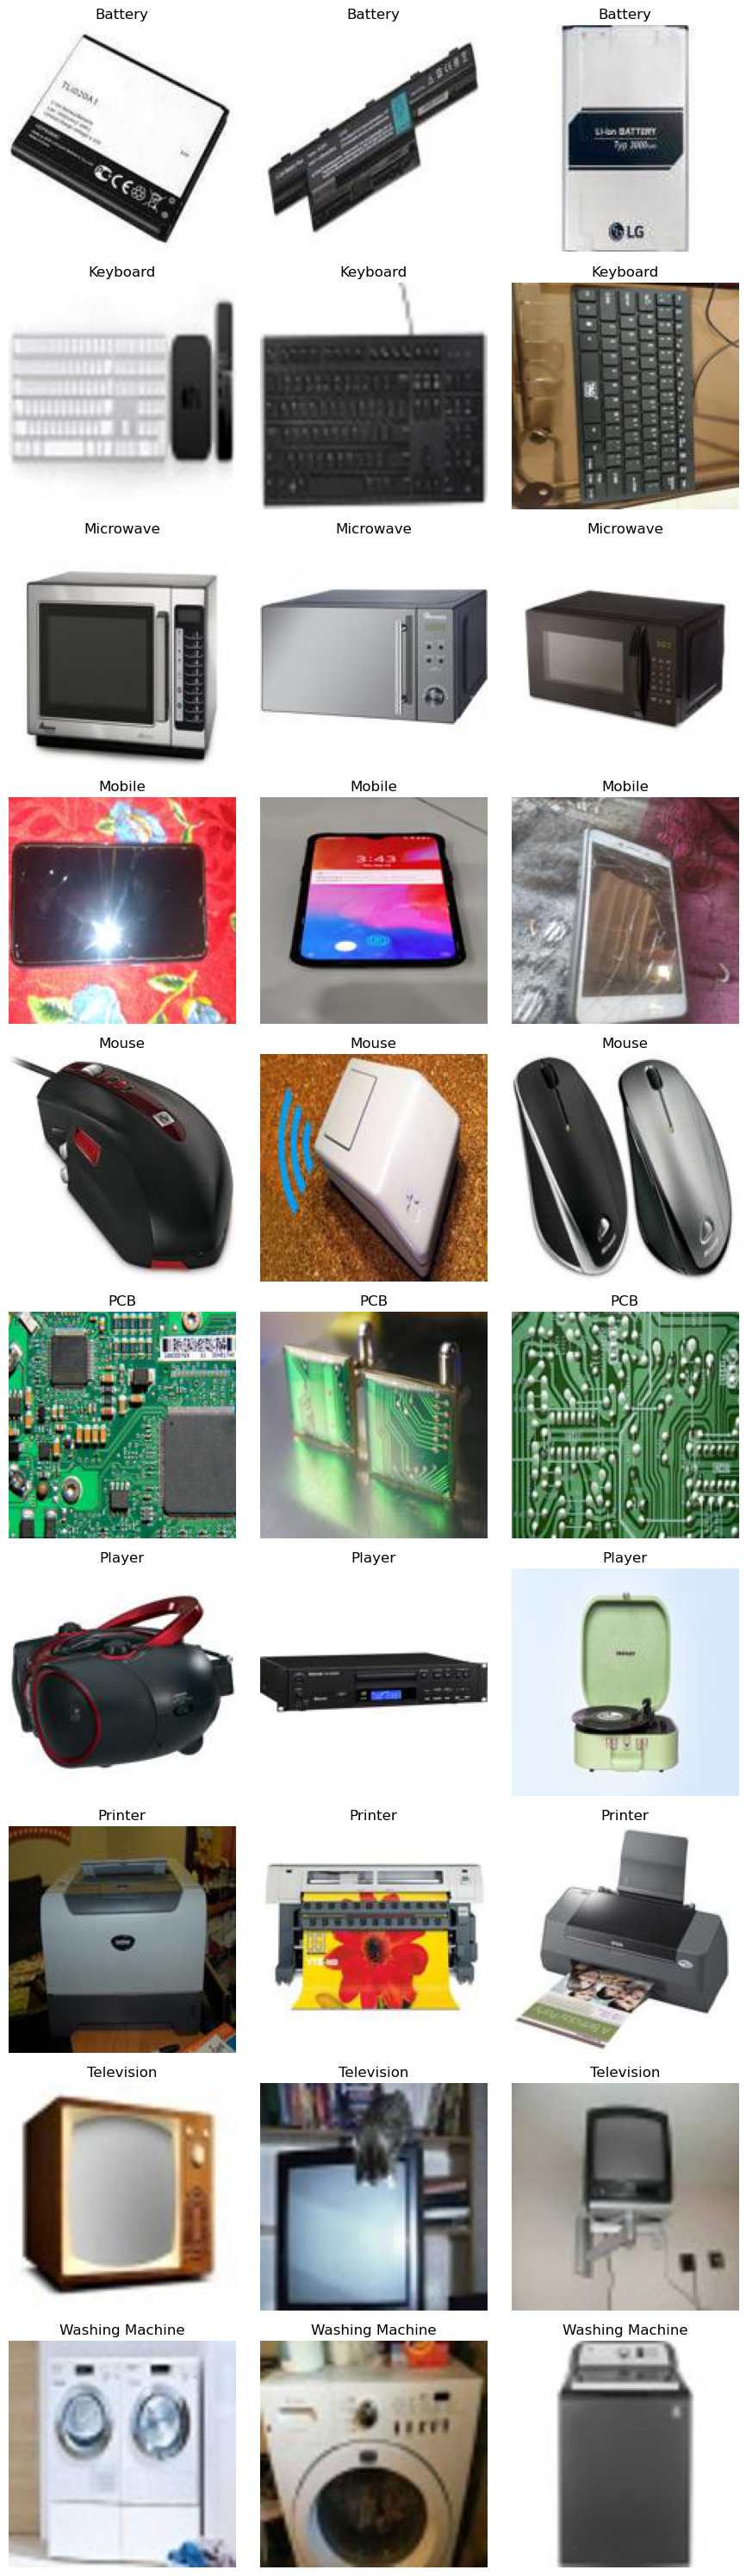

In [12]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Print the folder structure (for your reference)
def print_folder_structure(start_path, level=0):
    for root, dirs, files in os.walk(start_path):
        indent = ' ' * 4 * (root.count(os.sep) - start_path.count(os.sep))
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            print(f"{indent}    {f}")
        # Only go 3 levels deep
        if root.count(os.sep) - start_path.count(os.sep) >= 3:
            dirs[:] = []

# CHANGE this to your real dataset path
base_dir = "C:/Users/BHARANIDHARAN.S/unzipped_dataset/modified-dataset"

print("🔍 Folder Structure:")
print_folder_structure(base_dir)


# Step 2: Count images in each split (train, val, test)
def count_images_in_subfolders(root_dir):
    image_counts = {}
    if not os.path.exists(root_dir):
        print(f"❌ Error: {root_dir} does not exist.")
        return image_counts

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            image_counts[class_name] = len(image_files)
    return image_counts

# Choose one split at a time
split = "train"  # or "test" or "val"
split_path = os.path.join(base_dir, split)
image_counts = count_images_in_subfolders(split_path)

# Step 3: Visualize the class distribution
def plot_class_distribution(image_counts, title):
    if not image_counts:
        print("❌ No image data to display.")
        return

    classes = list(image_counts.keys())
    counts = list(image_counts.values())

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Image Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_class_distribution(image_counts, f"Image Count per Class - {split.upper()}")


# Step 4: Display random images from a few classes
def show_random_images(root_dir, classes=None, images_per_class=3):
    if not os.path.exists(root_dir):
        print(f"❌ {root_dir} not found.")
        return

    if classes is None:
        classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]

    plt.figure(figsize=(images_per_class * 3, len(classes) * 3))

    img_index = 1
    for cls in classes:
        class_dir = os.path.join(root_dir, cls)
        img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random_imgs = random.sample(img_files, min(images_per_class, len(img_files)))

        for img_name in random_imgs:
            img_path = os.path.join(class_dir, img_name)
            try:
                img = Image.open(img_path)
                plt.subplot(len(classes), images_per_class, img_index)
                plt.imshow(img)
                plt.title(cls)
                plt.axis('off')
                img_index += 1
            except Exception as e:
                print(f"❌ Error displaying image: {img_path}, Error: {e}")
    plt.tight_layout()
    plt.show()

# Show random images from the training set
show_random_images(split_path, images_per_class=3)
